# Phase 5 — Statistical Validation and Robustness

This notebook evaluates the uncertainty and statistical significance of the
frozen holdout results.

It does not modify:

- the factor-collapse definition,
- the frozen excess-kurtosis detector,
- the 63-day diagnostic window,
- the 252-day historical standardization window,
- the 2.0 warning threshold,
- or the primary 126-trading-day attribution horizon.

Analyses:

1. Bootstrap confidence intervals
2. Circular-shift random-warning benchmark
3. Pooled and factor-level permutation p-values
4. Multiple-testing correction
5. Sensitivity to the warning-attribution horizon

In [1]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(
    "/content/drive/MyDrive/When_Do_Factor_Premia_Break"
)

PROCESSED = ROOT / "data" / "processed"
RESULTS = ROOT / "data" / "results"

FACTOR_INPUT = (
    PROCESSED / "factor_returns_daily.parquet"
)

COLLAPSE_EVENTS_INPUT = (
    RESULTS / "collapse_events.csv"
)

HOLDOUT_EVENTS_INPUT = (
    RESULTS / "holdout_event_results.csv"
)

HOLDOUT_WARNINGS_INPUT = (
    RESULTS / "holdout_warning_results.csv"
)

FACTOR_METRICS_INPUT = (
    RESULTS / "holdout_factor_metrics.csv"
)

POOLED_METRICS_INPUT = (
    RESULTS / "holdout_pooled_metrics.csv"
)

FROZEN_CONFIG_INPUT = (
    RESULTS / "frozen_diagnostic_parameters.json"
)



Mounted at /content/drive


In [2]:
factors = pd.read_parquet(
    FACTOR_INPUT
)

collapse_events = pd.read_csv(
    COLLAPSE_EVENTS_INPUT,
    parse_dates=[
        "collapse_start",
        "collapse_end",
    ],
)

holdout_event_results = pd.read_csv(
    HOLDOUT_EVENTS_INPUT,
    parse_dates=[
        "collapse_start",
        "collapse_end",
        "warning_window_start",
        "matched_warning_date",
    ],
)

holdout_warning_results = pd.read_csv(
    HOLDOUT_WARNINGS_INPUT,
    parse_dates=[
        "warning_date",
    ],
)

factor_metrics = pd.read_csv(
    FACTOR_METRICS_INPUT
)

pooled_metrics = pd.read_csv(
    POOLED_METRICS_INPUT
)

with open(
    FROZEN_CONFIG_INPUT,
    "r",
    encoding="utf-8",
) as file:
    frozen_config = json.load(file)

print("Factors:", factors.shape)
print("Holdout collapse events:", len(holdout_event_results))
print("Warning events:", len(holdout_warning_results))
print("Frozen status:", frozen_config["status"])

Factors: (15833, 7)
Holdout collapse events: 86
Warning events: 536
Frozen status: FROZEN


In [3]:
FACTOR_COLUMNS = [
    "MKT_RF",
    "SMB",
    "HML",
    "RMW",
    "CMA",
    "MOM",
]

PRIMARY_HORIZON = int(
    frozen_config[
        "warning_to_collapse_horizon_days"
    ]
)

DEVELOPMENT_FACTOR = frozen_config[
    "factor_used_for_development"
]

DEVELOPMENT_COLLAPSE_START = pd.Timestamp(
    frozen_config[
        "development_collapse_start"
    ]
)

assert frozen_config["status"] == "FROZEN"
assert PRIMARY_HORIZON == 126

assert isinstance(
    factors.index,
    pd.DatetimeIndex,
)

assert factors.index.is_unique
assert factors.index.is_monotonic_increasing

assert set(
    holdout_event_results["factor"]
).issubset(FACTOR_COLUMNS)

assert set(
    holdout_warning_results["factor"]
).issubset(FACTOR_COLUMNS)

assert (
    (
        holdout_event_results["factor"]
        == DEVELOPMENT_FACTOR
    )
    & (
        holdout_event_results[
            "collapse_start"
        ]
        == DEVELOPMENT_COLLAPSE_START
    )
).sum() == 0

print("✓ Frozen holdout inputs passed validation")

✓ Frozen holdout inputs passed validation


In [4]:
def safe_divide(
    numerator: float,
    denominator: float,
) -> float:
    if denominator == 0:
        return np.nan

    return numerator / denominator

observed_event_count = len(
    holdout_event_results
)

observed_detected_count = int(
    holdout_event_results[
        "detected"
    ].sum()
)

observed_warning_count = len(
    holdout_warning_results
)

observed_true_positive_warnings = int(
    (
        holdout_warning_results[
            "classification"
        ]
        == "true_positive"
    ).sum()
)

observed_recall = safe_divide(
    observed_detected_count,
    observed_event_count,
)

observed_precision = safe_divide(
    observed_true_positive_warnings,
    observed_warning_count,
)

observed_lead_times = (
    holdout_event_results.loc[
        holdout_event_results["detected"],
        "lead_time_days",
    ]
    .dropna()
    .astype(float)
)

observed_median_lead = (
    observed_lead_times.median()
)

observed_summary = pd.DataFrame(
    [
        {
            "collapse_events":
                observed_event_count,
            "detected_events":
                observed_detected_count,
            "warning_events":
                observed_warning_count,
            "true_positive_warnings":
                observed_true_positive_warnings,
            "recall":
                observed_recall,
            "precision":
                observed_precision,
            "median_lead_time_days":
                observed_median_lead,
        }
    ]
)

observed_summary

assert np.isclose(
    observed_recall,
    pooled_metrics.loc[0, "recall"],
)

assert np.isclose(
    observed_precision,
    pooled_metrics.loc[0, "precision"],
)

assert np.isclose(
    observed_median_lead,
    pooled_metrics.loc[
        0,
        "median_lead_time_days",
    ],
)

print("✓ Primary metrics reproduced exactly")

✓ Primary metrics reproduced exactly


In [5]:
RANDOM_SEED = 20260731
BOOTSTRAP_REPLICATIONS = 10_000

rng = np.random.default_rng(
    RANDOM_SEED
)

def percentile_interval(
    values: np.ndarray,
    confidence_level: float = 0.95,
) -> tuple[float, float]:
    """
    Return a percentile bootstrap confidence interval.
    """
    values = np.asarray(
        values,
        dtype=float,
    )

    values = values[
        np.isfinite(values)
    ]

    alpha = 1.0 - confidence_level

    lower = np.quantile(
        values,
        alpha / 2,
    )

    upper = np.quantile(
        values,
        1 - alpha / 2,
    )

    return float(lower), float(upper)

def bootstrap_recall_once(
    event_results: pd.DataFrame,
    factors_to_use: list[str],
    generator: np.random.Generator,
) -> float:
    """
    Resample collapse events within each factor.
    """
    sampled_detection_values = []

    for factor in factors_to_use:
        factor_values = (
            event_results.loc[
                event_results["factor"]
                == factor,
                "detected",
            ]
            .astype(int)
            .to_numpy()
        )

        if len(factor_values) == 0:
            continue

        sample = generator.choice(
            factor_values,
            size=len(factor_values),
            replace=True,
        )

        sampled_detection_values.extend(
            sample.tolist()
        )

    if not sampled_detection_values:
        return np.nan

    return float(
        np.mean(sampled_detection_values)
    )

def bootstrap_precision_once(
    warning_results: pd.DataFrame,
    factors_to_use: list[str],
    generator: np.random.Generator,
) -> float:
    """
    Resample warning classifications within each factor.
    """
    sampled_true_positive_values = []

    for factor in factors_to_use:
        factor_values = (
            warning_results.loc[
                warning_results["factor"]
                == factor,
                "classification",
            ]
            .eq("true_positive")
            .astype(int)
            .to_numpy()
        )

        if len(factor_values) == 0:
            continue

        sample = generator.choice(
            factor_values,
            size=len(factor_values),
            replace=True,
        )

        sampled_true_positive_values.extend(
            sample.tolist()
        )

    if not sampled_true_positive_values:
        return np.nan

    return float(
        np.mean(sampled_true_positive_values)
    )


def bootstrap_median_lead_once(
    event_results: pd.DataFrame,
    factors_to_use: list[str],
    generator: np.random.Generator,
) -> float:
    """
    Resample detected-event lead times within each factor.
    """
    sampled_lead_times = []

    for factor in factors_to_use:
        factor_values = (
            event_results.loc[
                (
                    event_results["factor"]
                    == factor
                )
                & event_results["detected"],
                "lead_time_days",
            ]
            .dropna()
            .astype(float)
            .to_numpy()
        )

        if len(factor_values) == 0:
            continue

        sample = generator.choice(
            factor_values,
            size=len(factor_values),
            replace=True,
        )

        sampled_lead_times.extend(
            sample.tolist()
        )

    if not sampled_lead_times:
        return np.nan

    return float(
        np.median(sampled_lead_times)
    )

bootstrap_recall = np.empty(
    BOOTSTRAP_REPLICATIONS
)

bootstrap_precision = np.empty(
    BOOTSTRAP_REPLICATIONS
)

bootstrap_median_lead = np.empty(
    BOOTSTRAP_REPLICATIONS
)

for replication in range(
    BOOTSTRAP_REPLICATIONS
):
    bootstrap_recall[
        replication
    ] = bootstrap_recall_once(
        holdout_event_results,
        FACTOR_COLUMNS,
        rng,
    )

    bootstrap_precision[
        replication
    ] = bootstrap_precision_once(
        holdout_warning_results,
        FACTOR_COLUMNS,
        rng,
    )

    bootstrap_median_lead[
        replication
    ] = bootstrap_median_lead_once(
        holdout_event_results,
        FACTOR_COLUMNS,
        rng,
    )

recall_ci = percentile_interval(
    bootstrap_recall
)

precision_ci = percentile_interval(
    bootstrap_precision
)

median_lead_ci = percentile_interval(
    bootstrap_median_lead
)

bootstrap_summary = pd.DataFrame(
    [
        {
            "metric": "recall",
            "estimate": observed_recall,
            "ci_lower": recall_ci[0],
            "ci_upper": recall_ci[1],
        },
        {
            "metric": "precision",
            "estimate": observed_precision,
            "ci_lower": precision_ci[0],
            "ci_upper": precision_ci[1],
        },
        {
            "metric":
                "median_lead_time_days",
            "estimate":
                observed_median_lead,
            "ci_lower":
                median_lead_ci[0],
            "ci_upper":
                median_lead_ci[1],
        },
    ]
)

bootstrap_summary

,metric,estimate,ci_lower,ci_upper
0,recall,0.488372,0.383721,0.593023
1,precision,0.078358,0.055970,0.100746
2,median_lead_time_days,66.000000,46.000000,91.000000


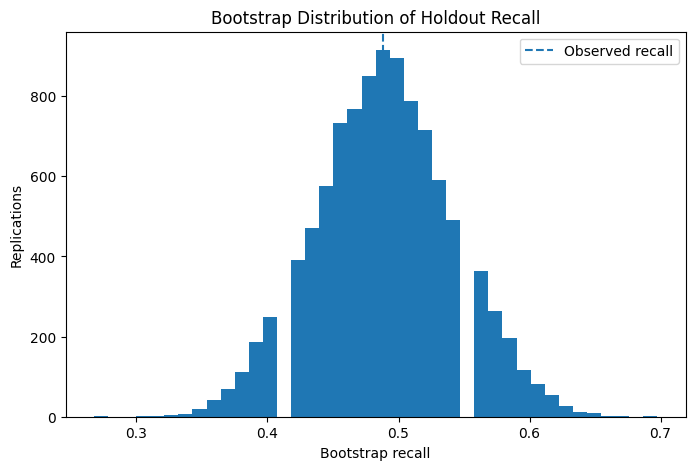

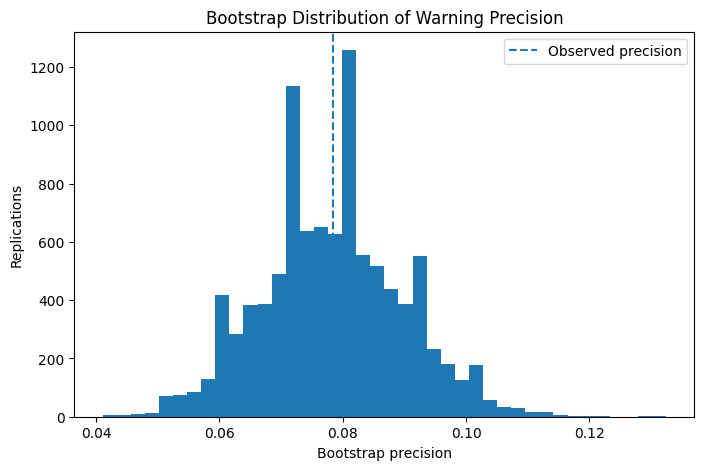

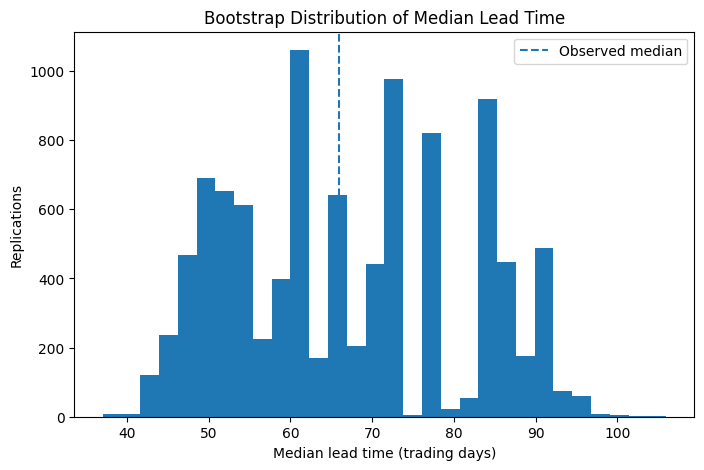

In [6]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.hist(
    bootstrap_recall,
    bins=40,
)

ax.axvline(
    observed_recall,
    linestyle="--",
    label="Observed recall",
)

ax.set_xlabel("Bootstrap recall")
ax.set_ylabel("Replications")
ax.set_title(
    "Bootstrap Distribution of Holdout Recall"
)
ax.legend()

plt.show()

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.hist(
    bootstrap_precision,
    bins=40,
)

ax.axvline(
    observed_precision,
    linestyle="--",
    label="Observed precision",
)

ax.set_xlabel("Bootstrap precision")
ax.set_ylabel("Replications")
ax.set_title(
    "Bootstrap Distribution of Warning Precision"
)
ax.legend()

plt.show()

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.hist(
    bootstrap_median_lead[
        np.isfinite(
            bootstrap_median_lead
        )
    ],
    bins=30,
)

ax.axvline(
    observed_median_lead,
    linestyle="--",
    label="Observed median",
)

ax.set_xlabel(
    "Median lead time (trading days)"
)

ax.set_ylabel("Replications")

ax.set_title(
    "Bootstrap Distribution of Median Lead Time"
)

ax.legend()
plt.show()

In [7]:
def match_warnings_to_events(
    factor: str,
    factor_index: pd.DatetimeIndex,
    warning_dates: pd.DatetimeIndex,
    factor_events: pd.DataFrame,
    warning_horizon: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Match the earliest unmatched warning in each collapse's
    pre-event horizon.

    Each warning and collapse can be matched at most once.
    """
    warning_dates = pd.DatetimeIndex(
        sorted(pd.DatetimeIndex(
            warning_dates
        ).unique())
    )

    factor_events = (
        factor_events
        .sort_values("collapse_start")
        .reset_index(drop=True)
    )

    used_warning_dates = set()
    event_records = []

    for event in factor_events.itertuples(
        index=False
    ):
        collapse_start = pd.Timestamp(
            event.collapse_start
        )

        collapse_position = (
            factor_index.get_indexer(
                [collapse_start]
            )[0]
        )

        if collapse_position == -1:
            raise ValueError(
                f"{factor}: collapse date "
                f"{collapse_start.date()} "
                "not found in the index."
            )

        window_start_position = max(
            0,
            collapse_position
            - warning_horizon,
        )

        window_start = factor_index[
            window_start_position
        ]

        eligible_warnings = [
            warning_date
            for warning_date in warning_dates
            if (
                window_start
                <= warning_date
                < collapse_start
            )
            and warning_date
            not in used_warning_dates
        ]

        if eligible_warnings:
            matched_warning = min(
                eligible_warnings
            )

            warning_position = (
                factor_index.get_indexer(
                    [matched_warning]
                )[0]
            )

            lead_time = (
                collapse_position
                - warning_position
            )

            detected = True

            used_warning_dates.add(
                matched_warning
            )
        else:
            matched_warning = pd.NaT
            lead_time = np.nan
            detected = False

        event_records.append(
            {
                "factor": factor,
                "collapse_start":
                    collapse_start,
                "detected":
                    detected,
                "matched_warning_date":
                    matched_warning,
                "lead_time_days":
                    lead_time,
            }
        )

    warning_records = [
        {
            "factor": factor,
            "warning_date": warning_date,
            "classification": (
                "true_positive"
                if warning_date
                in used_warning_dates
                else "false_positive"
            ),
        }
        for warning_date in warning_dates
    ]

    return (
        pd.DataFrame(event_records),
        pd.DataFrame(warning_records),
    )

In [8]:
holdout_events_for_matching = (
    holdout_event_results[
        [
            "factor",
            "collapse_start",
            "collapse_end",
        ]
    ]
    .copy()
)

observed_warning_dates_by_factor = {
    factor: pd.DatetimeIndex(
        holdout_warning_results.loc[
            holdout_warning_results[
                "factor"
            ]
            == factor,
            "warning_date",
        ]
        .sort_values()
        .unique()
    )
    for factor in FACTOR_COLUMNS
}

reproduced_event_results = []
reproduced_warning_results = []

for factor in FACTOR_COLUMNS:
    factor_event_output, factor_warning_output = (
        match_warnings_to_events(
            factor=factor,
            factor_index=factors.index,
            warning_dates=(
                observed_warning_dates_by_factor[
                    factor
                ]
            ),
            factor_events=(
                holdout_events_for_matching.loc[
                    holdout_events_for_matching[
                        "factor"
                    ]
                    == factor
                ]
            ),
            warning_horizon=PRIMARY_HORIZON,
        )
    )

    reproduced_event_results.append(
        factor_event_output
    )

    reproduced_warning_results.append(
        factor_warning_output
    )

reproduced_event_results = pd.concat(
    reproduced_event_results,
    ignore_index=True,
)

reproduced_warning_results = pd.concat(
    reproduced_warning_results,
    ignore_index=True,
)

reproduced_recall = (
    reproduced_event_results[
        "detected"
    ].mean()
)

reproduced_precision = (
    reproduced_warning_results[
        "classification"
    ].eq("true_positive").mean()
)

assert np.isclose(
    reproduced_recall,
    observed_recall,
)

assert np.isclose(
    reproduced_precision,
    observed_precision,
)

print("✓ Matching function reproduces primary metrics")

✓ Matching function reproduces primary metrics


In [9]:
PERMUTATION_REPLICATIONS = 5_000

permutation_rng = np.random.default_rng(
    RANDOM_SEED + 1
)

def circular_shift_dates(
    dates: pd.DatetimeIndex,
    full_index: pd.DatetimeIndex,
    shift: int,
) -> pd.DatetimeIndex:
    """
    Circularly shift event dates along a trading-date index.
    """
    if len(dates) == 0:
        return pd.DatetimeIndex([])

    positions = full_index.get_indexer(
        dates
    )

    if (positions == -1).any():
        raise ValueError(
            "At least one warning date was not "
            "found in the full index."
        )

    shifted_positions = (
        positions + shift
    ) % len(full_index)

    shifted_dates = full_index[
        shifted_positions
    ]

    return pd.DatetimeIndex(
        sorted(pd.unique(shifted_dates))
    )

def evaluate_warning_date_sets(
    warning_dates_by_factor: dict,
    factor_events: pd.DataFrame,
    factor_index: pd.DatetimeIndex,
    warning_horizon: int,
) -> dict:
    """
    Evaluate pooled and factor-level performance.
    """
    all_event_results = []
    all_warning_results = []

    for factor in FACTOR_COLUMNS:
        event_output, warning_output = (
            match_warnings_to_events(
                factor=factor,
                factor_index=factor_index,
                warning_dates=(
                    warning_dates_by_factor[
                        factor
                    ]
                ),
                factor_events=(
                    factor_events.loc[
                        factor_events["factor"]
                        == factor
                    ]
                ),
                warning_horizon=warning_horizon,
            )
        )

        all_event_results.append(
            event_output
        )

        all_warning_results.append(
            warning_output
        )

    all_event_results = pd.concat(
        all_event_results,
        ignore_index=True,
    )

    all_warning_results = pd.concat(
        all_warning_results,
        ignore_index=True,
    )

    pooled_recall = (
        all_event_results[
            "detected"
        ].mean()
    )

    pooled_precision = (
        all_warning_results[
            "classification"
        ].eq("true_positive").mean()
    )

    detected_lead_times = (
        all_event_results.loc[
            all_event_results["detected"],
            "lead_time_days",
        ]
        .dropna()
    )

    factor_recall = (
        all_event_results
        .groupby("factor")["detected"]
        .mean()
        .reindex(FACTOR_COLUMNS)
    )

    return {
        "recall": pooled_recall,
        "precision": pooled_precision,
        "median_lead_time_days": (
            detected_lead_times.median()
            if len(detected_lead_times)
            else np.nan
        ),
        "factor_recall":
            factor_recall,
    }


null_recall = np.empty(
    PERMUTATION_REPLICATIONS
)

null_precision = np.empty(
    PERMUTATION_REPLICATIONS
)

null_median_lead = np.empty(
    PERMUTATION_REPLICATIONS
)

null_factor_recall = pd.DataFrame(
    index=range(
        PERMUTATION_REPLICATIONS
    ),
    columns=FACTOR_COLUMNS,
    dtype=float,
)

for replication in range(
    PERMUTATION_REPLICATIONS
):
    shifted_warning_dates = {}

    for factor in FACTOR_COLUMNS:
        observed_dates = (
            observed_warning_dates_by_factor[
                factor
            ]
        )

        if len(observed_dates) == 0:
            shifted_warning_dates[
                factor
            ] = pd.DatetimeIndex([])

            continue

        shift = int(
            permutation_rng.integers(
                1,
                len(factors.index),
            )
        )

        shifted_warning_dates[
            factor
        ] = circular_shift_dates(
            dates=observed_dates,
            full_index=factors.index,
            shift=shift,
        )

    simulation_result = (
        evaluate_warning_date_sets(
            warning_dates_by_factor=(
                shifted_warning_dates
            ),
            factor_events=(
                holdout_events_for_matching
            ),
            factor_index=factors.index,
            warning_horizon=PRIMARY_HORIZON,
        )
    )

    null_recall[
        replication
    ] = simulation_result["recall"]

    null_precision[
        replication
    ] = simulation_result["precision"]

    null_median_lead[
        replication
    ] = simulation_result[
        "median_lead_time_days"
    ]

    null_factor_recall.loc[
        replication
    ] = simulation_result[
        "factor_recall"
    ]

In [10]:
def upper_tail_permutation_pvalue(
    observed: float,
    null_values: np.ndarray,
) -> float:
    """
    Calculate a one-sided permutation p-value.
    """
    null_values = np.asarray(
        null_values,
        dtype=float,
    )

    null_values = null_values[
        np.isfinite(null_values)
    ]

    exceedances = np.sum(
        null_values >= observed
    )

    return float(
        (exceedances + 1)
        / (len(null_values) + 1)
    )

pooled_recall_pvalue = (
    upper_tail_permutation_pvalue(
        observed_recall,
        null_recall,
    )
)

pooled_precision_pvalue = (
    upper_tail_permutation_pvalue(
        observed_precision,
        null_precision,
    )
)

permutation_summary = pd.DataFrame(
    [
        {
            "metric": "recall",
            "observed":
                observed_recall,
            "null_mean":
                np.nanmean(null_recall),
            "null_median":
                np.nanmedian(null_recall),
            "null_95th_percentile":
                np.nanquantile(
                    null_recall,
                    0.95,
                ),
            "permutation_pvalue":
                pooled_recall_pvalue,
        },
        {
            "metric": "precision",
            "observed":
                observed_precision,
            "null_mean":
                np.nanmean(null_precision),
            "null_median":
                np.nanmedian(null_precision),
            "null_95th_percentile":
                np.nanquantile(
                    null_precision,
                    0.95,
                ),
            "permutation_pvalue":
                pooled_precision_pvalue,
        },
    ]
)

permutation_summary

,metric,observed,null_mean,null_median,null_95th_percentile,permutation_pvalue
0,recall,0.488372,0.429342,0.430233,0.523256,0.164167
1,precision,0.078358,0.068887,0.069030,0.083955,0.164167


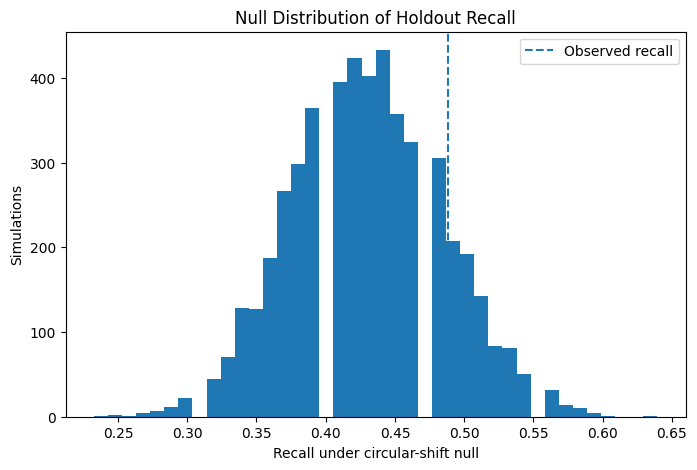

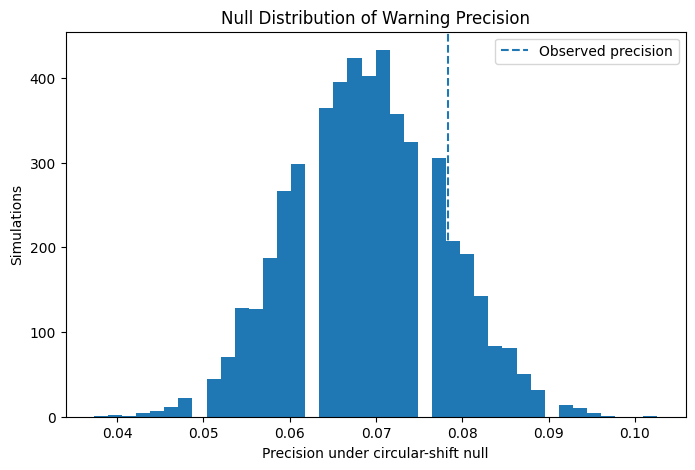

In [11]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.hist(
    null_recall,
    bins=40,
)

ax.axvline(
    observed_recall,
    linestyle="--",
    label="Observed recall",
)

ax.set_xlabel(
    "Recall under circular-shift null"
)

ax.set_ylabel("Simulations")

ax.set_title(
    "Null Distribution of Holdout Recall"
)

ax.legend()
plt.show()

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.hist(
    null_precision,
    bins=40,
)

ax.axvline(
    observed_precision,
    linestyle="--",
    label="Observed precision",
)

ax.set_xlabel(
    "Precision under circular-shift null"
)

ax.set_ylabel("Simulations")

ax.set_title(
    "Null Distribution of Warning Precision"
)

ax.legend()
plt.show()

In [12]:
def wilson_interval(
    successes: int,
    trials: int,
    z: float = 1.959963984540054,
) -> tuple[float, float]:
    """
    Wilson score interval for a binomial proportion.
    """
    if trials == 0:
        return np.nan, np.nan

    proportion = successes / trials

    denominator = (
        1
        + z**2 / trials
    )

    center = (
        proportion
        + z**2 / (2 * trials)
    ) / denominator

    half_width = (
        z
        * np.sqrt(
            (
                proportion
                * (1 - proportion)
                / trials
            )
            + (
                z**2
                / (4 * trials**2)
            )
        )
        / denominator
    )

    return (
        max(0.0, center - half_width),
        min(1.0, center + half_width),
    )

factor_validation_records = []

for factor in FACTOR_COLUMNS:
    factor_events = (
        holdout_event_results.loc[
            holdout_event_results[
                "factor"
            ]
            == factor
        ]
    )

    event_count = len(
        factor_events
    )

    detected_count = int(
        factor_events[
            "detected"
        ].sum()
    )

    recall = safe_divide(
        detected_count,
        event_count,
    )

    interval_lower, interval_upper = (
        wilson_interval(
            detected_count,
            event_count,
        )
    )

    factor_null_values = (
        null_factor_recall[
            factor
        ].to_numpy(
            dtype=float
        )
    )

    factor_pvalue = (
        upper_tail_permutation_pvalue(
            recall,
            factor_null_values,
        )
    )

    factor_validation_records.append(
        {
            "factor": factor,
            "collapse_events":
                event_count,
            "detected_events":
                detected_count,
            "recall":
                recall,
            "recall_ci_lower":
                interval_lower,
            "recall_ci_upper":
                interval_upper,
            "null_mean_recall":
                np.nanmean(
                    factor_null_values
                ),
            "raw_permutation_pvalue":
                factor_pvalue,
        }
    )

factor_validation = pd.DataFrame(
    factor_validation_records
)

factor_validation

,factor,collapse_events,detected_events,recall,recall_ci_lower,recall_ci_upper,null_mean_recall,raw_permutation_pvalue
0,MKT_RF,17,6,0.352941,0.173097,0.586996,0.348412,0.573285
1,SMB,16,10,0.625000,0.386410,0.815188,0.422725,0.086983
2,HML,14,6,0.428571,0.213808,0.674094,0.420971,0.564887
3,RMW,13,8,0.615385,0.355229,0.822903,0.472000,0.217357
4,CMA,11,4,0.363636,0.151665,0.646199,0.451600,0.818036
5,MOM,15,8,0.533333,0.301170,0.751905,0.482640,0.440512


In [13]:
def benjamini_hochberg(
    pvalues: pd.Series,
) -> pd.Series:
    """
    Return Benjamini-Hochberg adjusted p-values.
    """
    pvalues = pd.Series(
        pvalues,
        dtype=float,
    )

    number_of_tests = len(
        pvalues
    )

    order = np.argsort(
        pvalues.to_numpy()
    )

    ranked_pvalues = (
        pvalues.to_numpy()[order]
    )

    adjusted_ranked = (
        ranked_pvalues
        * number_of_tests
        / np.arange(
            1,
            number_of_tests + 1,
        )
    )

    adjusted_ranked = np.minimum.accumulate(
        adjusted_ranked[::-1]
    )[::-1]

    adjusted_ranked = np.clip(
        adjusted_ranked,
        0,
        1,
    )

    adjusted = np.empty(
        number_of_tests,
        dtype=float,
    )

    adjusted[order] = (
        adjusted_ranked
    )

    return pd.Series(
        adjusted,
        index=pvalues.index,
    )

raw_pvalues = factor_validation[
    "raw_permutation_pvalue"
]

factor_validation[
    "bh_fdr_adjusted_pvalue"
] = benjamini_hochberg(
    raw_pvalues
)

factor_validation[
    "bonferroni_adjusted_pvalue"
] = np.minimum(
    raw_pvalues
    * len(raw_pvalues),
    1.0,
)

factor_validation[
    "significant_bh_5pct"
] = (
    factor_validation[
        "bh_fdr_adjusted_pvalue"
    ]
    <= 0.05
)

factor_validation[
    "significant_bonferroni_5pct"
] = (
    factor_validation[
        "bonferroni_adjusted_pvalue"
    ]
    <= 0.05
)

factor_validation

,factor,collapse_events,detected_events,recall,recall_ci_lower,recall_ci_upper,null_mean_recall,raw_permutation_pvalue,bh_fdr_adjusted_pvalue,bonferroni_adjusted_pvalue,significant_bh_5pct,significant_bonferroni_5pct
0,MKT_RF,17,6,0.352941,0.173097,0.586996,0.348412,0.573285,0.687942,1.000000,False,False
1,SMB,16,10,0.625000,0.386410,0.815188,0.422725,0.086983,0.521896,0.521896,False,False
2,HML,14,6,0.428571,0.213808,0.674094,0.420971,0.564887,0.687942,1.000000,False,False
3,RMW,13,8,0.615385,0.355229,0.822903,0.472000,0.217357,0.652070,1.000000,False,False
4,CMA,11,4,0.363636,0.151665,0.646199,0.451600,0.818036,0.818036,1.000000,False,False
5,MOM,15,8,0.533333,0.301170,0.751905,0.482640,0.440512,0.687942,1.000000,False,False


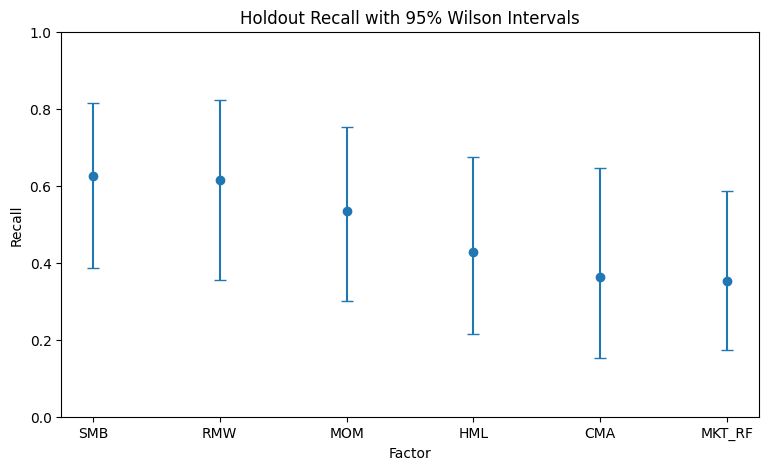

In [14]:
plot_data = (
    factor_validation
    .sort_values(
        "recall",
        ascending=False,
    )
    .reset_index(drop=True)
)

lower_error = (
    plot_data["recall"]
    - plot_data[
        "recall_ci_lower"
    ]
)

upper_error = (
    plot_data[
        "recall_ci_upper"
    ]
    - plot_data["recall"]
)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.errorbar(
    plot_data["factor"],
    plot_data["recall"],
    yerr=np.vstack(
        [
            lower_error,
            upper_error,
        ]
    ),
    fmt="o",
    capsize=4,
)

ax.set_ylim(0, 1)

ax.set_xlabel("Factor")
ax.set_ylabel("Recall")

ax.set_title(
    "Holdout Recall with 95% Wilson Intervals"
)

plt.show()

✓ 126-day sensitivity row matches primary metrics


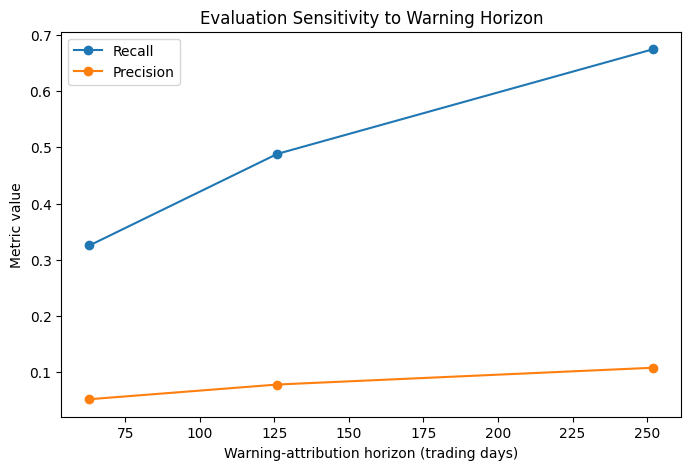

In [15]:
SENSITIVITY_HORIZONS = [
    63,
    126,
    252,
]

horizon_sensitivity_records = []

for horizon in SENSITIVITY_HORIZONS:
    evaluation = evaluate_warning_date_sets(
        warning_dates_by_factor=(
            observed_warning_dates_by_factor
        ),
        factor_events=(
            holdout_events_for_matching
        ),
        factor_index=factors.index,
        warning_horizon=horizon,
    )

    horizon_sensitivity_records.append(
        {
            "warning_horizon_days":
                horizon,
            "recall":
                evaluation["recall"],
            "precision":
                evaluation["precision"],
            "median_lead_time_days":
                evaluation[
                    "median_lead_time_days"
                ],
        }
    )

horizon_sensitivity = pd.DataFrame(
    horizon_sensitivity_records
)

horizon_sensitivity

primary_sensitivity_row = (
    horizon_sensitivity.loc[
        horizon_sensitivity[
            "warning_horizon_days"
        ]
        == PRIMARY_HORIZON
    ]
    .iloc[0]
)

assert np.isclose(
    primary_sensitivity_row[
        "recall"
    ],
    observed_recall,
)

assert np.isclose(
    primary_sensitivity_row[
        "precision"
    ],
    observed_precision,
)

print("✓ 126-day sensitivity row matches primary metrics")

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    horizon_sensitivity[
        "warning_horizon_days"
    ],
    horizon_sensitivity[
        "recall"
    ],
    marker="o",
    label="Recall",
)

ax.plot(
    horizon_sensitivity[
        "warning_horizon_days"
    ],
    horizon_sensitivity[
        "precision"
    ],
    marker="o",
    label="Precision",
)

ax.set_xlabel(
    "Warning-attribution horizon "
    "(trading days)"
)

ax.set_ylabel("Metric value")

ax.set_title(
    "Evaluation Sensitivity to Warning Horizon"
)

ax.legend()
plt.show()

In [16]:
statistical_summary = pd.DataFrame(
    [
        {
            "holdout_collapse_events":
                observed_event_count,
            "detected_events":
                observed_detected_count,
            "warning_events":
                observed_warning_count,

            "recall":
                observed_recall,
            "recall_ci_lower":
                recall_ci[0],
            "recall_ci_upper":
                recall_ci[1],

            "precision":
                observed_precision,
            "precision_ci_lower":
                precision_ci[0],
            "precision_ci_upper":
                precision_ci[1],

            "median_lead_time_days":
                observed_median_lead,
            "median_lead_ci_lower":
                median_lead_ci[0],
            "median_lead_ci_upper":
                median_lead_ci[1],

            "null_mean_recall":
                np.nanmean(
                    null_recall
                ),
            "recall_permutation_pvalue":
                pooled_recall_pvalue,

            "null_mean_precision":
                np.nanmean(
                    null_precision
                ),
            "precision_permutation_pvalue":
                pooled_precision_pvalue,

            "bootstrap_replications":
                BOOTSTRAP_REPLICATIONS,
            "permutation_replications":
                PERMUTATION_REPLICATIONS,
            "random_seed":
                RANDOM_SEED,
        }
    ]
)

statistical_summary

,holdout_collapse_events,detected_events,warning_events,recall,recall_ci_lower,recall_ci_upper,precision,precision_ci_lower,precision_ci_upper,median_lead_time_days,median_lead_ci_lower,median_lead_ci_upper,null_mean_recall,recall_permutation_pvalue,null_mean_precision,precision_permutation_pvalue,bootstrap_replications,permutation_replications,random_seed
0,86,42,536,0.488372,0.383721,0.593023,0.078358,0.05597,0.100746,66.0,46.0,91.0,0.429342,0.164167,0.068887,0.164167,10000,5000,20260731


In [17]:
BOOTSTRAP_SUMMARY_OUTPUT = (
    RESULTS
    / "statistical_bootstrap_summary.csv"
)

PERMUTATION_SUMMARY_OUTPUT = (
    RESULTS
    / "statistical_permutation_summary.csv"
)

FACTOR_VALIDATION_OUTPUT = (
    RESULTS
    / "statistical_factor_validation.csv"
)

HORIZON_SENSITIVITY_OUTPUT = (
    RESULTS
    / "statistical_horizon_sensitivity.csv"
)

STATISTICAL_SUMMARY_OUTPUT = (
    RESULTS
    / "statistical_validation_summary.csv"
)

NULL_DISTRIBUTIONS_OUTPUT = (
    RESULTS
    / "statistical_null_distributions.parquet"
)

bootstrap_summary.to_csv(
    BOOTSTRAP_SUMMARY_OUTPUT,
    index=False,
)

permutation_summary.to_csv(
    PERMUTATION_SUMMARY_OUTPUT,
    index=False,
)

factor_validation.to_csv(
    FACTOR_VALIDATION_OUTPUT,
    index=False,
)

horizon_sensitivity.to_csv(
    HORIZON_SENSITIVITY_OUTPUT,
    index=False,
)

statistical_summary.to_csv(
    STATISTICAL_SUMMARY_OUTPUT,
    index=False,
)

null_distributions = pd.DataFrame(
    {
        "null_recall":
            null_recall,
        "null_precision":
            null_precision,
        "null_median_lead_time_days":
            null_median_lead,
    }
)

null_distributions.to_parquet(
    NULL_DISTRIBUTIONS_OUTPUT,
    index=False,
)

print("✓ Statistical-validation outputs saved")

✓ Statistical-validation outputs saved


In [18]:
bootstrap_summary_reload = pd.read_csv(
    BOOTSTRAP_SUMMARY_OUTPUT
)

permutation_summary_reload = pd.read_csv(
    PERMUTATION_SUMMARY_OUTPUT
)

factor_validation_reload = pd.read_csv(
    FACTOR_VALIDATION_OUTPUT
)

horizon_sensitivity_reload = pd.read_csv(
    HORIZON_SENSITIVITY_OUTPUT
)

statistical_summary_reload = pd.read_csv(
    STATISTICAL_SUMMARY_OUTPUT
)

pd.testing.assert_frame_equal(
    bootstrap_summary,
    bootstrap_summary_reload,
    check_dtype=False,
    check_exact=False,
    rtol=1e-10,
    atol=1e-12,
)

pd.testing.assert_frame_equal(
    permutation_summary,
    permutation_summary_reload,
    check_dtype=False,
    check_exact=False,
    rtol=1e-10,
    atol=1e-12,
)

pd.testing.assert_frame_equal(
    factor_validation,
    factor_validation_reload,
    check_dtype=False,
    check_exact=False,
    rtol=1e-10,
    atol=1e-12,
)

pd.testing.assert_frame_equal(
    horizon_sensitivity,
    horizon_sensitivity_reload,
    check_dtype=False,
    check_exact=False,
    rtol=1e-10,
    atol=1e-12,
)

pd.testing.assert_frame_equal(
    statistical_summary,
    statistical_summary_reload,
    check_dtype=False,
    check_exact=False,
    rtol=1e-10,
    atol=1e-12,
)

print("✓ Saved tables reload correctly")

✓ Saved tables reload correctly


In [19]:
print("=" * 72)
print("STATISTICAL VALIDATION COMPLETE")
print("=" * 72)

print(
    f"Observed recall: "
    f"{observed_recall:.3f}"
)

print(
    "Recall 95% bootstrap CI:",
    (
        round(recall_ci[0], 3),
        round(recall_ci[1], 3),
    ),
)

print(
    f"Observed precision: "
    f"{observed_precision:.3f}"
)

print(
    "Precision 95% bootstrap CI:",
    (
        round(precision_ci[0], 3),
        round(precision_ci[1], 3),
    ),
)

print(
    f"Observed median lead time: "
    f"{observed_median_lead:.1f} days"
)

print(
    "Median lead-time 95% bootstrap CI:",
    (
        round(median_lead_ci[0], 1),
        round(median_lead_ci[1], 1),
    ),
)

print(
    f"Null mean recall: "
    f"{np.nanmean(null_recall):.3f}"
)

print(
    f"Recall permutation p-value: "
    f"{pooled_recall_pvalue:.4f}"
)

print(
    f"Null mean precision: "
    f"{np.nanmean(null_precision):.3f}"
)

print(
    f"Precision permutation p-value: "
    f"{pooled_precision_pvalue:.4f}"
)

print("\nSaved outputs:")

for path in [
    BOOTSTRAP_SUMMARY_OUTPUT,
    PERMUTATION_SUMMARY_OUTPUT,
    FACTOR_VALIDATION_OUTPUT,
    HORIZON_SENSITIVITY_OUTPUT,
    STATISTICAL_SUMMARY_OUTPUT,
    NULL_DISTRIBUTIONS_OUTPUT,
]:
    print(" -", path.name)

STATISTICAL VALIDATION COMPLETE
Observed recall: 0.488
Recall 95% bootstrap CI: (0.384, 0.593)
Observed precision: 0.078
Precision 95% bootstrap CI: (0.056, 0.101)
Observed median lead time: 66.0 days
Median lead-time 95% bootstrap CI: (46.0, 91.0)
Null mean recall: 0.429
Recall permutation p-value: 0.1642
Null mean precision: 0.069
Precision permutation p-value: 0.1642

Saved outputs:
 - statistical_bootstrap_summary.csv
 - statistical_permutation_summary.csv
 - statistical_factor_validation.csv
 - statistical_horizon_sensitivity.csv
 - statistical_validation_summary.csv
 - statistical_null_distributions.parquet


### Statistical Validation

The frozen excess-kurtosis detector identified 42 of 86 holdout collapse events, corresponding to a recall of 48.8%. A factor-stratified bootstrap produced a 95% confidence interval of 38.4% to 59.3%. Warning-event precision was 7.8%, with a 95% bootstrap interval of 5.6% to 10.1%. For detected events, the median lead time was 66 trading days, with a 95% bootstrap interval of 46 to 91 days.

To test whether this performance reflected meaningful temporal alignment rather than warning frequency alone, warning dates were circularly shifted within each factor while preserving warning counts and spacing. Under this null model, mean recall was 42.9%, compared with observed recall of 48.8%. The one-sided permutation p-value was 0.164. Mean null precision was 6.9%, compared with observed precision of 7.8%, also yielding a p-value of 0.164.

Therefore, the frozen detector exhibited modest descriptive improvement over the circular-shift benchmark, but the improvement was not statistically significant at conventional levels. No individual factor remained significant after Benjamini–Hochberg or Bonferroni correction. These findings are consistent with either a weak signal or insufficient power given the limited number of collapse events.
